# Polynomial Regression 

 What if you data has some combination of higher order behaviour
 may be some curve valleys  which can possibly be represented 
 by combination of X1, X2, X1², X1 × X2, X2² ?

In [10]:
# Lets prepare some no-linear data

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

np.random.seed(42)
SIZE=200
X1=np.random.randint(800,2200,size=SIZE)
X2=np.random.randint(1,5,size=SIZE)
noise=np.random.normal(0,100,size=SIZE)

Y=12*X1 + 50* X2 + 10* X1*X2  +X1**2  +500 + noise

df=pd.DataFrame({
    "X1_area":X1,
    "X2_rooms":X2,
    "Price_Y":Y,
})

df.head(100)

,X1_area,X2_rooms,Price_Y
0,1926,4,3.810349e+06
1,1660,2,2.809195e+06
2,2094,4,4.494441e+06
3,1930,3,3.806649e+06
4,1895,4,3.690177e+06
...,...,...,...
95,814,1,6.811128e+05
96,864,4,7.921521e+05
97,1320,4,1.811678e+06
98,2167,2,4.765812e+06


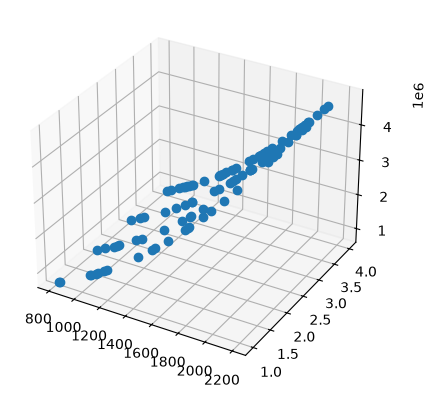

In [13]:
# Plot  3d
plt.figure()
plt.axes(projection='3d')
plt.plot(X1[:100],X2[:100],Y[:100],'o')
plt.show()

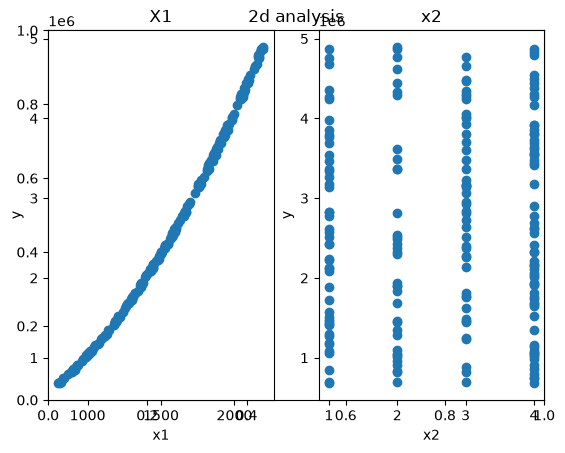

In [16]:
# 2d analysis
plt.title("2d analysis")
plt.subplot(1,2,1)
plt.title("X1")
plt.xlabel("x1")
plt.ylabel("y")
plt.scatter(X1,Y,)

plt.subplot(1,2,2)
plt.title("x2")
plt.xlabel("x2")
plt.ylabel("y")
plt.scatter(X2,Y)

plt.show()

# Conclusion 

Data is not linear in nature . We have to try some kind of non linear equations .


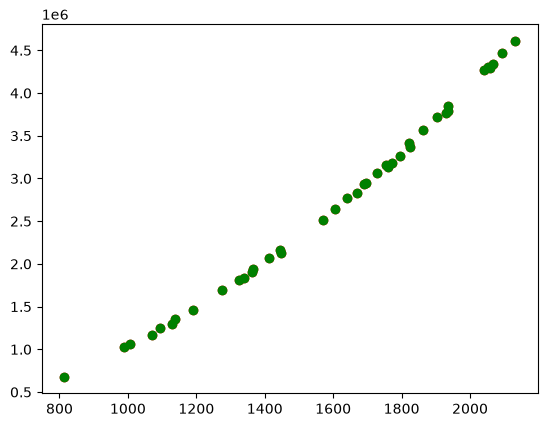

[681050.33377864]


In [30]:
from sklearn.preprocessing import PolynomialFeatures
from sklearn.linear_model import LinearRegression
from sklearn.pipeline import make_pipeline
from sklearn.model_selection import train_test_split

# pipe line of x->x2 and then coefficient learning
model= make_pipeline(PolynomialFeatures(2,include_bias=False),LinearRegression())

X=np.column_stack((X1,X2))

x_train,x_test,y_train, y_test=train_test_split(X,Y,test_size=.2,random_state=42)

model.fit(x_train,y_train)

y_pred=model.predict(x_test)


# Some visualization
plt.plot(x_test[:,0],y_pred,'o',color='red')
plt.plot(x_test[:,0],y_test,'o',color="green")
plt.show()

#model works well ?
#scores ?
#validation
print(model.predict([x_test[0]]))



In [24]:
#metrics

from sklearn.metrics import r2_score ,root_mean_squared_error,mean_absolute_error

print("R2 score ", r2_score(y_test,y_pred))
print ("RMSE ", root_mean_squared_error(y_test,y_pred))



R2 score  0.9999999921826811
RMSE  97.6834791846284


In [26]:
#Dump model

import pickle
with open("polynomial.pkl","wb") as file:
    pickle.dump(model,file)

In [29]:
#load model again
model_=None
with open("polynomial.pkl","rb") as file:
    model=pickle.load(file)
print(x_test[0])
print(model.predict([x_test[0]]))

[814   1]
[681050.33377864]
